In [30]:
import os
import sys
from dotenv import load_dotenv
# Run this in a cell if you don't have it:
# !pip install yfinance

import pandas as pd
import yfinance as yf
from tqdm import tqdm # For a nice progress bar

# Load your data
df = pd.read_csv("ptr_trades_365d.csv")
df['filing_date'] = pd.to_datetime(df['filing_date'])

# Ensure DATABASE_URL (and any other secrets) from .env are loaded
# Ensure DATABASE_URL (and any other secrets) from .env are loaded
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# Make sure the project root (which contains db/, scraper/, app/) is on sys.path
if project_root not in sys.path:  # <--- NEW
    sys.path.insert(0, project_root)

load_dotenv(os.path.join(project_root, '.env'))

from app.data_access import load_trades_df

df = load_trades_df(days=365)  # or 90, etc.
print(df.shape)      # rows, columns
print(df.tail())     # first 5 rows

# If you want to inspect some columns only:
print(df[["filing_date", "transaction_date", "ticker", "senator_display_name", "mid_point"]].tail(20))
# df.to_csv("ptr_trades_365d.csv", index=False)
# print("Wrote ptr_trades_365d.csv with", len(df), "rows")


(594, 27)
       id  senator_name senator_first_name senator_last_name  \
589  1516  John Boozman               John           Boozman   
590  1510  John Boozman               John           Boozman   
591  1446  John Boozman               John           Boozman   
592  1445  John Boozman               John           Boozman   
593  1444  John Boozman               John           Boozman   

        senator_display_name chamber                             report_id  \
589  Boozman, John (Senator)  Senate  6cf4a78e-92f0-4201-bf73-e9b02cd8f9ef   
590  Boozman, John (Senator)  Senate  6cf4a78e-92f0-4201-bf73-e9b02cd8f9ef   
591  Boozman, John (Senator)  Senate  b6f24083-8ed9-4368-b482-3d14155c1e9b   
592  Boozman, John (Senator)  Senate  b6f24083-8ed9-4368-b482-3d14155c1e9b   
593  Boozman, John (Senator)  Senate  b6f24083-8ed9-4368-b482-3d14155c1e9b   

    report_type report_format filing_date  ...  amount_range_raw amount_min  \
589         PTR           ptr  2025-03-06  ...  $1,001 - 

# Data Cleaning

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already ran your data_access code:
# df = pd.read_csv("ptr_trades_365d.csv")

# For the sake of this tutorial, let's ensure dates are correct
df['filing_date'] = pd.to_datetime(df['filing_date'])
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Clean up transaction types to simple BUY/SELL
df['type'] = df['transaction_type'].str.upper()

# Helper Functions

In [32]:
def calculate_return(row):
    # Avoid division by zero
    if row['price_at_transaction'] == 0 or pd.isna(row['price_at_transaction']):
        return 0
    
    # Simple Return: (Current - Entry) / Entry
    ret = (row['current_price'] - row['price_at_transaction']) / row['price_at_transaction']
    
    # If they SOLD, a price drop is a "win" for the senator's timing
    if 'SELL' in row['type']:
        return -ret
    return ret

df['trade_return'] = df.apply(calculate_return, axis=1)
df['is_win'] = df['trade_return'] > 0

In [33]:
# Grouping data by Senator
leaderboard = df.groupby('senator_name').agg({
    'trade_return': 'mean',
    'is_win': 'mean',
    'id': 'count'
}).rename(columns={
    'trade_return': 'Avg_Return',
    'is_win': 'Hit_Rate',
    'id': 'Trade_Count'
}).sort_values(by='Avg_Return', ascending=False)

# Convert Hit_Rate to percentage
leaderboard['Hit_Rate'] = (leaderboard['Hit_Rate'] * 100).round(2)
leaderboard['Avg_Return'] = (leaderboard['Avg_Return'] * 100).round(2)

print("--- Senator Performance (Sorted by Avg Return) ---")
print(leaderboard)

--- Senator Performance (Sorted by Avg Return) ---
                            Avg_Return  Hit_Rate  Trade_Count
senator_name                                                 
John Fetterman                   95.56    100.00            1
John N Kennedy                   44.87    100.00            1
A. Mitchell McConnell, Jr.       37.37    100.00            6
Angus S King, Jr.                20.59     69.23           26
Bernie Moreno                    17.10    100.00            1
Markwayne Mullin                  8.99     52.74          146
Katie Britt                       8.97     52.17           23
Gary C Peters                     8.76     83.33            6
Lindsey Graham                    1.54     57.14            7
Jerry Moran,                      0.00     33.33            3
William F Hagerty, IV             0.00      0.00            1
Shelley M Capito                 -2.26     46.00           50
Tina Smith                       -2.78     25.00            4
John W Hickenlooper

In [34]:
# Filter for only BUY transactions
buys_df = df[df['type'].str.contains('BUY')].copy()

# Assume we invest $1000 per trade
investment_per_trade = 1000
buys_df['profit_usd'] = buys_df['trade_return'] * investment_per_trade

total_invested = len(buys_df) * investment_per_trade
total_profit = buys_df['profit_usd'].sum()
roi = (total_profit / total_invested) * 100

print(f"Strategy: Follow all BUY filings")
print(f"Total Trades: {len(buys_df)}")
print(f"Total Profit: ${total_profit:.2f}")
print(f"Strategy ROI: {roi:.2f}%")

Strategy: Follow all BUY filings
Total Trades: 307
Total Profit: $59890.29
Strategy ROI: 19.51%


In [35]:
# Load your data
df = pd.read_csv("ptr_trades_365d.csv")
df['filing_date'] = pd.to_datetime(df['filing_date'])

In [36]:
def get_filing_price(ticker, filing_date):
    try:
        # 1. Clean the ticker (BRK.B -> BRK-B)
        clean_ticker = str(ticker).replace('.', '-')
        
        # 2. Ensure date is YYYY-MM-DD string
        start_dt = filing_date.strftime('%Y-%m-%d')
        # Give a 7-day window to be safe for long holidays
        end_dt = (filing_date + pd.Timedelta(days=7)).strftime('%Y-%m-%d')
        
        t = yf.Ticker(clean_ticker)
        
        # 3. Use period='1mo' or specific dates
        hist = t.history(start=start_dt, end=end_dt)
        
        if not hist.empty:
            return float(hist['Close'].iloc[0])
        
        return None
    except Exception as e:
        # Print the error for the first few to diagnose
        # print(f"Error for {ticker} on {filing_date}: {e}")
        return None

# --- CRITICAL FIX: Standardize dates before running ---
buys_df['filing_date'] = pd.to_datetime(buys_df['filing_date'])

print("Fetching historical prices for filing dates...")
tqdm.pandas()

buys_df['price_at_filing'] = buys_df.progress_apply(
    lambda x: get_filing_price(x['ticker'], x['filing_date']), axis=1
)

print(f"Successfully retrieved {buys_df['price_at_filing'].notna().sum()} prices.")
print(df)

Fetching historical prices for filing dates...


100%|██████████| 307/307 [00:15<00:00, 19.55it/s]

Successfully retrieved 305 prices.
       id  senator_name senator_first_name senator_last_name  \
0    1268  John Boozman               John           Boozman   
1    1267  John Boozman               John           Boozman   
2    1255  John Boozman               John           Boozman   
3    1266  John Boozman               John           Boozman   
4    1264  John Boozman               John           Boozman   
..    ...           ...                ...               ...   
589  1516  John Boozman               John           Boozman   
590  1510  John Boozman               John           Boozman   
591  1446  John Boozman               John           Boozman   
592  1445  John Boozman               John           Boozman   
593  1444  John Boozman               John           Boozman   

        senator_display_name chamber                             report_id  \
0    Boozman, John (Senator)  Senate  135ebfe9-099e-4d58-ba46-f739b90d61da   
1    Boozman, John (Senator)  Senate  13

In [37]:
# 1. Copy-Trade Return (from Filing)
buys_df['copy_return'] = (buys_df['current_price'] - buys_df['price_at_filing']) / buys_df['price_at_filing']

# 2. Senator's Real Return (from Transaction)
buys_df['senator_return'] = (buys_df['current_price'] - buys_df['price_at_transaction']) / buys_df['price_at_transaction']

# 3. The "Information Gap" (How much did the stock move between their trade and the filing?)
buys_df['info_gap_pct'] = (buys_df['price_at_filing'] - buys_df['price_at_transaction']) / buys_df['price_at_transaction']

# Summary by Senator
strategy_summary = buys_df.groupby('senator_name').agg({
    'senator_return': 'mean',
    'copy_return': 'mean',
    'info_gap_pct': 'mean',
    'id': 'count'
}).sort_values(by='copy_return', ascending=False)
strategy_summary = strategy_summary.rename(columns={'id': 'total_trades'})

print("\n--- Strategy Results: Buying at Filing Date ---")
print(strategy_summary)


--- Strategy Results: Buying at Filing Date ---
                            senator_return  copy_return  info_gap_pct  \
senator_name                                                            
Jerry Moran,                      0.955571     0.812778      0.078771   
John Fetterman                    0.955571     0.775528      0.101403   
Shelley M Capito                  0.359116     0.370701      0.002217   
John N Kennedy                    0.448692     0.321709      0.096075   
A. Mitchell McConnell, Jr.        0.157863     0.142112      0.022141   
Gary C Peters                     0.126106     0.133432     -0.005084   
Angus S King, Jr.                 0.240404     0.116273      0.114655   
John Boozman                      0.127766     0.107472      0.020528   
Sheldon Whitehouse                0.093423     0.098539     -0.004541   
Markwayne Mullin                  0.365989     0.064227      0.289903   
Thomas H Tuberville               0.077797     0.050832      0.025684   
Li

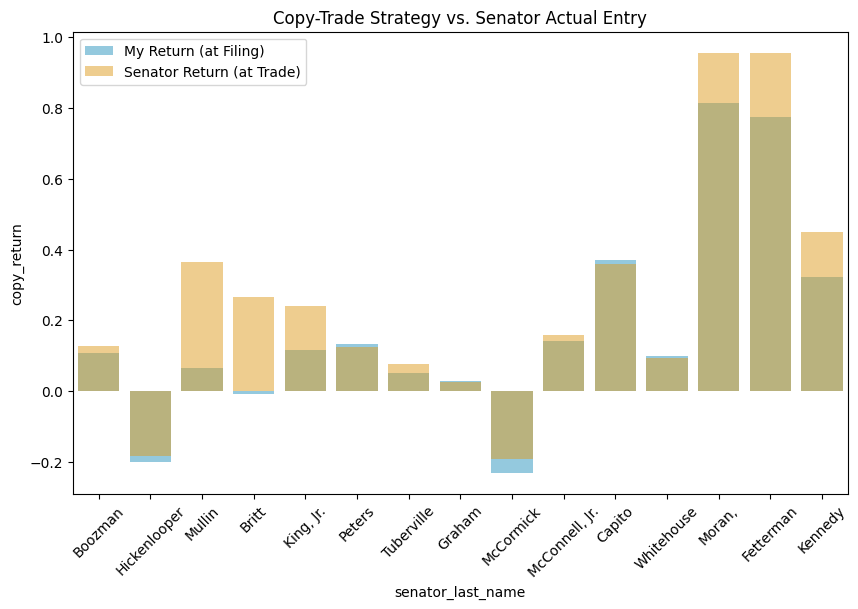

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=buys_df, x='senator_last_name', y='copy_return', errorbar=None,color='skyblue', label='My Return (at Filing)')
sns.barplot(data=buys_df, x='senator_last_name', y='senator_return',errorbar=None, alpha=0.5, color='orange', label='Senator Return (at Trade)')
plt.xticks(rotation=45)
plt.title("Copy-Trade Strategy vs. Senator Actual Entry")
plt.legend()
plt.show()

In [39]:
# 1. Ensure we are only looking at BUY trades with valid filing prices
# We filter out any rows where the price lookup might have failed
strategy_df = buys_df[buys_df['price_at_filing'].notna()].copy()

# 2. Assume we invest $1,000 per filing
investment_per_trade = 1000

# 3. Calculate Profit based on the Copy-Trade Return
# Formula: (Current Price / Price at Filing - 1) * Investment
strategy_df['copy_profit_usd'] = strategy_df['copy_return'] * investment_per_trade

# 4. Calculate Global Metrics
total_trades = len(strategy_df)
total_invested = total_trades * investment_per_trade
total_profit = strategy_df['copy_profit_usd'].sum()

# ROI Calculation: (Total Profit / Total Invested) * 100
strategy_roi = (total_profit / total_invested) * 100

print(f"--- Strategy: Copy-Trade at Filing Close ---")
print(f"Total Trades Analyzed: {total_trades}")
print(f"Total Capital Invested: ${total_invested:,.2f}")
print(f"Total Net Profit: ${total_profit:,.2f}")
print(f"Strategy ROI: {strategy_roi:.22f}%")

--- Strategy: Copy-Trade at Filing Close ---
Total Trades Analyzed: 305
Total Capital Invested: $305,000.00
Total Net Profit: $21,769.06
Strategy ROI: 7.1373951475367904961900%


In [40]:
sector_analysis = buys_df.groupby('sector').agg({
    'copy_return': 'mean',
    'id': 'count'
}).sort_values(by='copy_return', ascending=False)
print(sector_analysis)

                        copy_return  id
sector                                 
Communication Services     0.277126  22
Energy                     0.184254   5
Technology                 0.129408  48
Industrials                0.090691  12
Consumer Defensive         0.088659   7
Healthcare                 0.052438  14
Financial Services         0.006903  22
Consumer Cyclical         -0.010428  12
